# Notebook de documentacion, tratamiento datos y entrenamiento


## Autor
-  **Guillermo Ricci** - R-4711/2

# Librerias

In [2]:
# Librerías estándar del sistema
import sys
from pathlib import Path
from uuid import uuid4
import json 

# Computación científica y manejo de datos
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,pairwise)
from sklearn.metrics.pairwise import cosine_similarity

# Procesamiento de imágenes y visualización
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Deep Learning 
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from facenet_pytorch import MTCNN, InceptionResnetV1

from lib.storage.pgvector_store import PgVectorEmbeddingStore
from lib.schemas import EmbeddingRecord



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

d:\TUIA\VISION POR COMPUTADORA\tuia-face-recognition-app\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#  Dataset

Creamos un Dataset de **225 imágenes** en total, con **15 clases** distintas: 
* 10 personas del dataset de LFW (15 imágenes por cada una)
* 5 personas de un dataset propio (15 imágenes por cada una)

Al tener 15 imagenes por cada clase aseguramos un balance de las mismas. 
Luego aplicaremos Data Augmentation para obtener distintas variaciones.

Dataset LFW: https://www.kaggle.com/datasets/jessicali9530/lfw-dataset

In [4]:
# --- Configuración de datos ---
DATASET_PATH = Path("src/data/dataset_faces")
image_paths, labels = [], []

if DATASET_PATH.exists():
    # Obtenemos todos los directorios de personas
    person_dirs = sorted([d for d in DATASET_PATH.iterdir() if d.is_dir()])
    
    for person_dir in person_dirs:
        # Buscamos TODAS las imágenes .jpg en cada carpeta
        # Usamos glob("*.jpg") para obtener la lista completa
        current_person_images = list(person_dir.glob("*.jpg"))
        
        for img_path in current_person_images:
            image_paths.append(img_path)
            labels.append(person_dir.name)
            
    print(f"✅ Dataset cargado completamente")
    print(f"Total de personas: {len(np.unique(labels))}")
    print(f"Total de imágenes: {len(image_paths)}")
else:
    print(f"❌ Error: No se encontró la ruta {DATASET_PATH}")

✅ Dataset cargado completamente
Total de personas: 15
Total de imágenes: 225


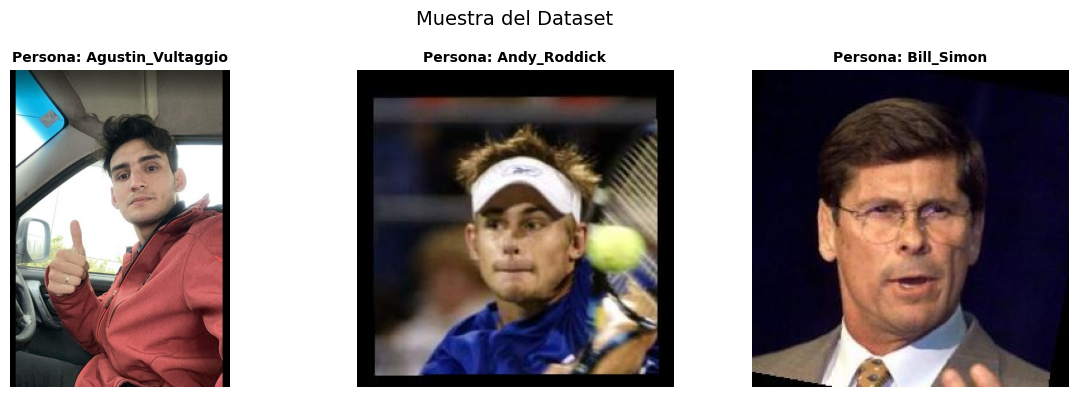

In [5]:
# Selección de muestra (3 personas distintas)
unique_labels = np.unique(labels)
sample_indices = []

# Buscamos el índice de la primera aparición de cada una de las primeras 3 personas
for label in unique_labels[:3]:
    idx = labels.index(label)
    sample_indices.append(idx)

# Mostrar resumen visual
if sample_indices:
    num_imgs = len(sample_indices)
    fig, axes = plt.subplots(1, num_imgs, figsize=(12, 4))
    
    # Manejo de caso con un solo subplot
    if num_imgs == 1: axes = [axes]
    
    for i, idx in enumerate(sample_indices):
        path = image_paths[idx]
        label = labels[idx]
        
        img = Image.open(path)
        axes[i].imshow(img)
        axes[i].set_title(f"Persona: {label}", fontsize=10, fontweight='bold')
        axes[i].axis("off")
    
    plt.suptitle("Muestra del Dataset", fontsize=14)
    plt.tight_layout()
    plt.show()

Division del Dataset en Train y Test (80/20)

In [6]:
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.20, stratify=labels, random_state=42
)

# Deteccion de rostros

Para la deteccion utilizaremos MTCNN que tiene **dos modos** de uso:

| Método | Qué devuelve | Para qué sirve |
|---|---|---|
| `detector.detect(img)` | boxes, probs, landmarks | **Detección**: saber dónde hay caras |
| `detector(img)` | tensor recortado y alineado | **Preprocesamiento**: cara lista para el modelo de embeddings |

El segundo modo recorta la cara usando los landmarks, la alinea y la redimensiona a 160×160.


In [7]:
# Inicializar MTCNN
# image_size=160: tamaño de la cara recortada (segun InceptionResnetV1)
# margin=20: píxeles extra alrededor de la cara al recortar
# keep_all=True: detectar TODAS las caras en la imagen
detector = MTCNN(image_size=160, margin=20, keep_all=True, device=device)
print(f"MTCNN inicializado en {device}")

MTCNN inicializado en cpu


In [8]:
# Función de Preprocesamiento  
def procesar_rostros(lista_paths, labels_originales):
    rostros_alineados = []
    etiquetas_finales = []
    
    print(f"Iniciando detección y alineación...")
    for path, label in zip(lista_paths, labels_originales):
        img = Image.open(path).convert('RGB')
        
        # El detector devuelve un tensor (C, H, W) ya normalizado  
        # MTCNN reescala a 160x160 para InceptionResnetV1
        cara_tensor = detector(img) 
        
        if cara_tensor is not None:
            # Si detectó varias caras, tomamos la primera [0]
            rostros_alineados.append(cara_tensor[0] if len(cara_tensor.shape)>3 else cara_tensor)
            etiquetas_finales.append(label)
            
    return torch.stack(rostros_alineados), etiquetas_finales

# Procesamos ambos sets
X_train, y_train = procesar_rostros(train_paths, train_labels)
X_test, y_test = procesar_rostros(test_paths, test_labels)

print(f"✅ Procesamiento finalizado. Rostros en Train: {X_train.shape[0]}")

Iniciando detección y alineación...


Iniciando detección y alineación...
✅ Procesamiento finalizado. Rostros en Train: 180


Realizamos una comparación: Original vs. Recortada y Alineada (Usando X_train)

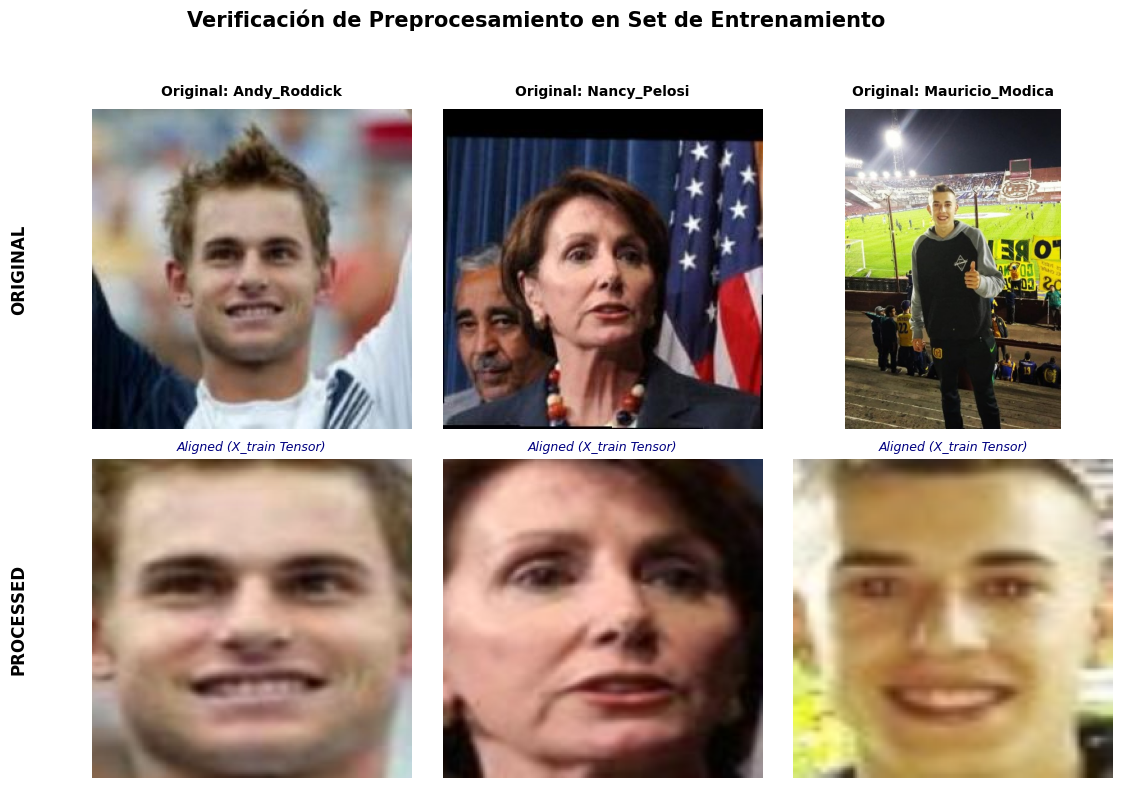

In [9]:
# Limitamos a un máximo de 3 imágenes para la visualización del set de TRAIN
num_show = min(3, len(X_train))
fig, axes = plt.subplots(2, num_show, figsize=(12, 8))

if num_show == 1:
    axes = axes.reshape(2, 1)

for i in range(num_show):
    # Carga de la imagen original usando train_paths
    # Usamos train_paths[i] para que coincida con el rostro en X_train[i]
    pil_img = Image.open(train_paths[i]).convert('RGB')
    
    # Obtención del rostro ya procesado de X_train
    # X_train[i] ya es un tensor (C, H, W) alineado por MTCNN
    cara_img_tensor = X_train[i]

    # FILA 0: Imagen Original 
    axes[0, i].imshow(pil_img)
    axes[0, i].set_title(f"Original: {y_train[i]}", fontsize=10, fontweight='bold', pad=10)
    axes[0, i].axis("off")

    # FILA 1: Cara Recortada y Alineada  
    # Permutamos de (C, H, W) a (H, W, C) y convertimos a numpy para visualización
    # Como MTCNN devuelve valores en el rango [-1, 1] o [0, 1] según config, aplicamos la normalización min-max  
    cara_img = cara_img_tensor.permute(1, 2, 0).cpu().numpy()
    cara_img = (cara_img - cara_img.min()) / (cara_img.max() - cara_img.min() + 1e-8)
    
    axes[1, i].imshow(cara_img)
    axes[1, i].set_title("Aligned (X_train Tensor)", fontsize=9, color='navy', style='italic')
    axes[1, i].axis("off")

# Configuración de Etiquetas Laterales 
axes[0, 0].text(-0.2, 0.5, "ORIGINAL", transform=axes[0, 0].transAxes, 
               fontsize=12, fontweight='bold', va='center', ha='right', rotation=90)

axes[1, 0].text(-0.2, 0.5, "PROCESSED", transform=axes[1, 0].transAxes, 
               fontsize=12, fontweight='bold', va='center', ha='right', rotation=90)

plt.suptitle("Verificación de Preprocesamiento en Set de Entrenamiento", y=0.98, fontsize=15, fontweight='black')
plt.tight_layout(rect=[0.05, 0, 1, 0.95])
plt.show()

 Analizamos como MTCNN localiza los rostros y landmarks

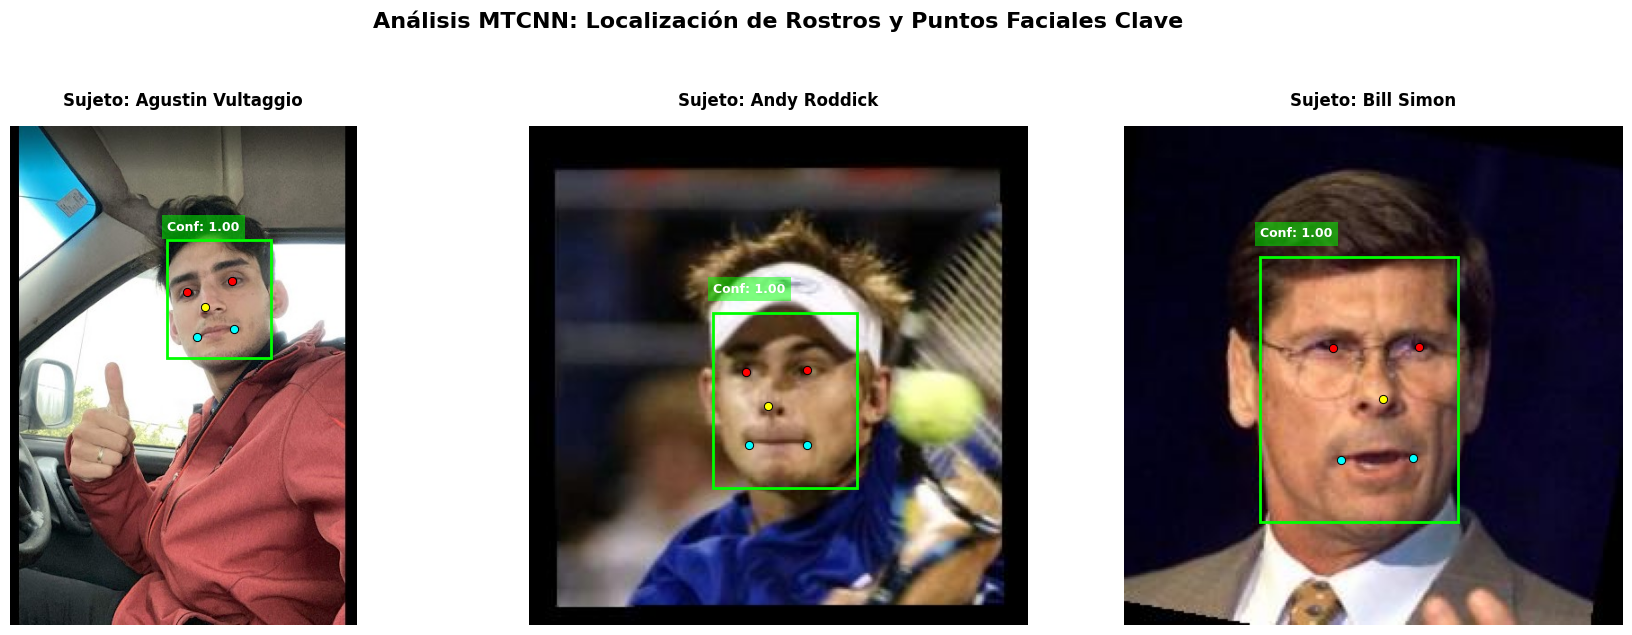

In [10]:
if image_paths:
    # Identificamos las primeras 3 personas distintas del dataset original
    # Usamos np.unique para asegurar variedad en la muestra
    unique_labels, first_indices = np.unique(labels, return_index=True)
    
    indices_para_mostrar = first_indices[:3]
    num_imgs = len(indices_para_mostrar)
    
    fig, axes = plt.subplots(1, num_imgs, figsize=(18, 6))
    
    if num_imgs == 1:
        axes = [axes]

    for i, idx in enumerate(indices_para_mostrar):
        path = image_paths[idx]
        label = labels[idx]
        ax = axes[i]
        
        # Carga de imagen
        pil_img = Image.open(path).convert('RGB')
        
        # Detección de puntos clave (Landmarks) y cajas
        # .detect() es ideal para este análisis porque nos da las coordenadas crudas
        boxes, probs, landmarks = detector.detect(pil_img, landmarks=True)

        ax.imshow(pil_img)

        if boxes is not None:
            for box, prob, lm in zip(boxes, probs, landmarks):
                # Dibujamos el Bounding Box
                x1, y1, x2, y2 = box.astype(int)
                rect = mpatches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    fill=False, color='lime', linewidth=2, zorder=10
                )
                ax.add_patch(rect)
                
                # Etiqueta de Confianza
                ax.text(x1, y1 - 10, f"Conf: {prob:.2f}", color='white', fontsize=9,
                        fontweight='bold', bbox=dict(facecolor='lime', alpha=0.5, edgecolor='none'))

                # Dibujamos los Landmarks (ojos, nariz, boca)
                colores_lm = ['red', 'red', 'yellow', 'cyan', 'cyan']
                for (lx, ly), c in zip(lm, colores_lm):
                    ax.scatter(lx, ly, c=c, s=35, edgecolors='black', linewidths=0.7, zorder=15)
        else:
            # --- Aviso visual si no hay detección ---
            ax.text(0.5, 0.5, "ROSTRO NO\nDETECTADO", 
                    transform=ax.transAxes, ha='center', va='center', 
                    color='white', fontweight='bold', fontsize=14,
                    bbox=dict(facecolor='red', alpha=0.6))

        # Configuración estética del eje
        ax.set_title(f"Sujeto: {label.replace('_', ' ')}", fontsize=12, fontweight='black', pad=15)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

    plt.suptitle("Análisis MTCNN: Localización de Rostros y Puntos Faciales Clave", 
                 y=1.05, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay imágenes cargadas para procesar.")

# Data Augmentation

In [11]:
# Codificamos los nombres (labels) a números (0, 1, 2...)
le = LabelEncoder()
y_train_idx = le.fit_transform(y_train)
y_test_idx = le.transform(y_test)

print(f"✅ Clases codificadas: {len(le.classes_)}")

✅ Clases codificadas: 15


A las imagenes de entrenamiento las transformamos con espejado, cambios de luz, rotaciones, ruido gaussiano y luego se normaliza.
Las imagenes de validacion solamente seran normalizadas.

In [12]:
# Estadísticas oficiales de ImageNet
img_net_mean = [0.485, 0.456, 0.406]
img_net_std = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Affine(translate_percent=0.05, scale=0.95, rotate=5, p=0.2),
    A.GaussNoise(p=0.1),
    # Especificamos que la entrada estará en 0-255
    A.Normalize(mean=img_net_mean, std=img_net_std, max_pixel_value=255.0),
    ToTensorV2()
])

In [13]:
# Estadísticas de ImageNet (estándar para modelos pre-entrenados)
img_net_mean = [0.485, 0.456, 0.406]
img_net_std = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),           # Espejado horizontal
    A.RandomBrightnessContrast(p=0.2), # Cambios leves de luz
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=5, p=0.2), # Movimientos mínimos
    A.GaussNoise(p=0.1), # Un poco de ruido
    A.Normalize(mean=img_net_mean, std=img_net_std),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(mean=img_net_mean, std=img_net_std),
    ToTensorV2()
])

d:\TUIA\VISION POR COMPUTADORA\tuia-face-recognition-app\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [14]:
class FaceDataset(Dataset):
    def __init__(self, images_tensor, labels, transform=None):
        self.images = images_tensor
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx] # Viene de MTCNN en rango [-1, 1]
        
        # Mapear de [-1, 1] a [0, 255] 
        # Sumamos 1 -> [0, 2], multiplicamos por 127.5 -> [0, 255]
        img = ((img + 1.0) * 127.5).clamp(0, 255).to(torch.uint8)
        
        # Convertir a NumPy (H, W, C) para Albumentations 
        img = img.permute(1, 2, 0).cpu().numpy()
        
        if self.transform:
            augmented = self.transform(image=img)
            img = augmented['image']
            
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

# Instanciar los datasets y loaders
train_ds = FaceDataset(X_train, y_train_idx, transform=train_transform)
test_ds = FaceDataset(X_test, y_test_idx, transform=val_transform)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

print(f"🚀 DataLoaders listos. Batches en Train: {len(train_loader)}")

🚀 DataLoaders listos. Batches en Train: 12


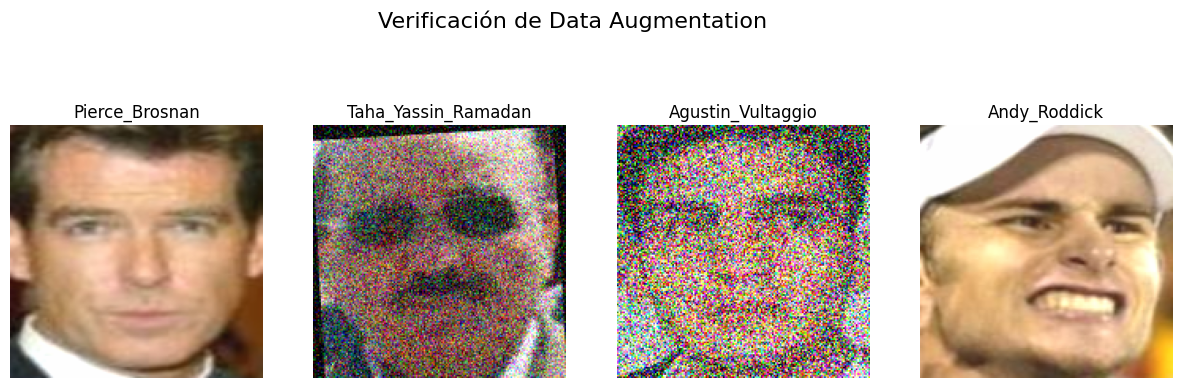

In [31]:
# Dataset con Corrección de Rango  
def visualizar_batch(loader, le):
    batch_imgs, batch_labels = next(iter(loader))
    fig, axes = plt.subplots(1, 4, figsize=(15, 5))
    
    # Convertimos listas a arrays de numpy para que la matemática sea correcta
    mean = np.array(img_net_mean)
    std = np.array(img_net_std)
    
    for i in range(4):
        # 1. Pasar a numpy y poner canales al final (H, W, C)
        img = batch_imgs[i].permute(1, 2, 0).numpy()
        
        # 2. DES-NORMALIZAR: (valor * std) + mean
        img = (img * std) + mean
        
        # 3. Clip por seguridad y graficar
        img = np.clip(img, 0, 1)
        
        axes[i].imshow(img)
        axes[i].set_title(le.inverse_transform([batch_labels[i]])[0])
        axes[i].axis('off')
    
    plt.suptitle("Verificación de Data Augmentation", fontsize=16)
    plt.show()

visualizar_batch(train_loader, le)

# Extraccion de Embeddings


Usamos **InceptionResnetV1** pre-entrenado en **VGGFace2** (3.3 millones de imágenes, 9131 identidades).

El modelo recibe una cara alineada de 160×160 y devuelve un **vector de 512 dimensiones**, normalizado (norma L2 = 1).

- **Misma persona** → embeddings **cercanos** (alta similitud coseno)
- **Personas distintas** → embeddings **lejanos** (baja similitud coseno)

Como los embeddings están L2-normalizados, la **similitud coseno = producto punto**:

$$\text{sim}(e_1, e_2) = e_1 \cdot e_2 = \cos(\theta)$$

In [16]:
# Modelo de embeddings faciales
modelo = InceptionResnetV1(pretrained='vggface2').eval().to(device)
print(f"InceptionResnetV1 cargado | Embedding: 512 dimensiones")
print(f"Parámetros: {sum(p.numel() for p in modelo.parameters()) / 1e6:.1f}M")

InceptionResnetV1 cargado | Embedding: 512 dimensiones
Parámetros: 27.9M


In [17]:
def generar_embeddings(loader, modelo):
    """Recorre el loader y devolverá los vectores y sus etiquetas."""
    list_embs = []
    list_labels = []
    
    print("🚀 Extrayendo características...")
    with torch.no_grad(): # Desactivamos gradientes para ahorrar memoria y tiempo
        for batch_imgs, batch_labels in loader:
            # Enviamos el batch al dispositivo (CPU/GPU)
            batch_imgs = batch_imgs.to(device)
            
            # El modelo genera el vector de 512-d
            # InceptionResnetV1 ya devuelve embeddings normalizados L2 por defecto
            embs = modelo(batch_imgs)
            
            list_embs.append(embs.cpu().numpy())
            list_labels.append(batch_labels.numpy())
            
    # Concatenamos todos los batches en un solo array de Numpy
    return np.vstack(list_embs), np.concatenate(list_labels)

In [18]:
# Generamos embeddings para la Galería (Train set)
# Usamos val_transform para que los vectores en la DB sean "limpios"
gallery_ds = FaceDataset(X_train, y_train_idx, transform=val_transform)
gallery_loader = DataLoader(gallery_ds, batch_size=32, shuffle=False)

train_embeddings, train_labels_idx = generar_embeddings(gallery_loader, modelo)

# Generamos embeddings para el Test (Queries) 
test_embeddings, test_labels_idx = generar_embeddings(test_loader, modelo)

# Recuperamos los nombres originales 
# Usamos el LabelEncoder 'le' que definimos antes
train_labels_names = le.inverse_transform(train_labels_idx)
test_labels_names = le.inverse_transform(test_labels_idx)

print(f"\n✅ Extracción completada:")
print(f"Galería: {train_embeddings.shape}")
print(f"Test/Queries: {test_embeddings.shape}")

🚀 Extrayendo características...
🚀 Extrayendo características...

✅ Extracción completada:
Galería: (180, 512)
Test/Queries: (45, 512)


# Visualizacion de clusters

Como los embeddings poseen 512 dimensiones, no podemos graficarlos directamente. Entonces realizaremos una reduccion de dimensionalidad utilizando t-SNE que es una técnica de aprendizaje automático no supervisado, especializada en visualizar conjuntos de datos complejos de alta dimensión en un espacio de 2D 

Generando visualización t-SNE para 180 imágenes...


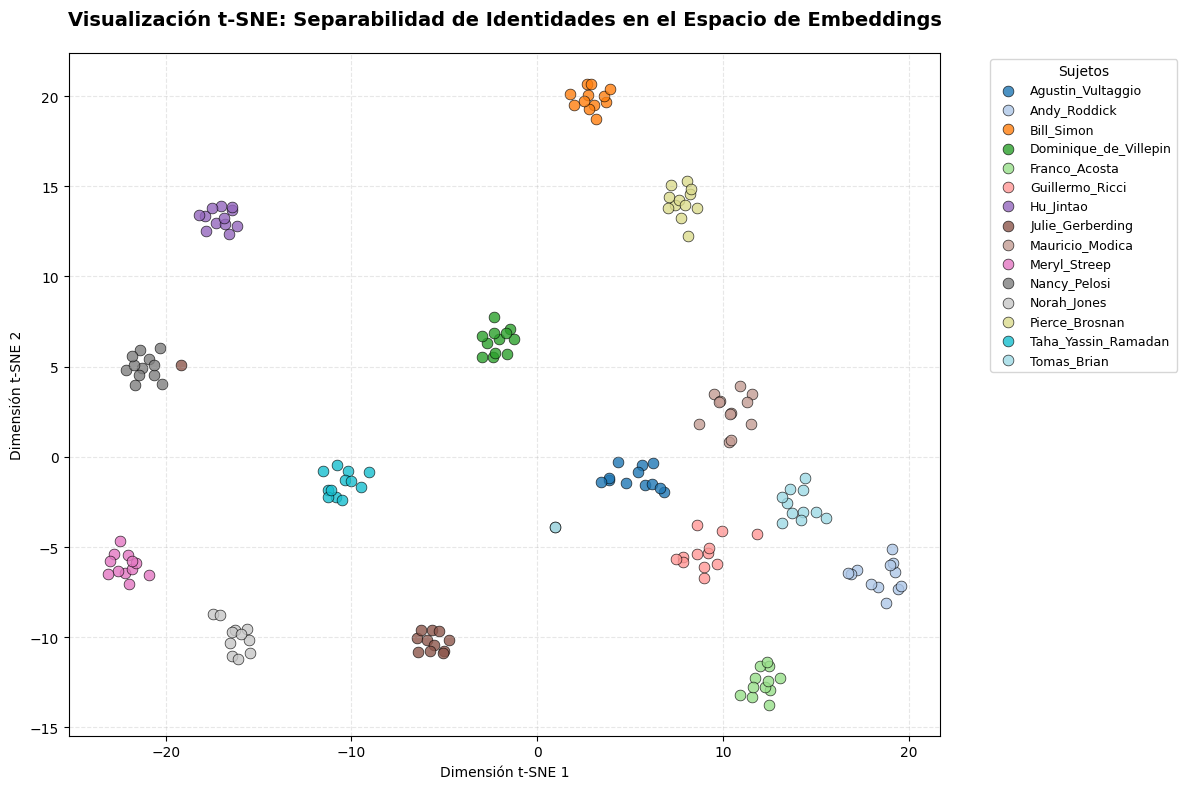

In [19]:
# Preparar los datos (usamos el set de entrenamiento/galería)
# train_embeddings: (N, 512)
# train_labels_names: nombres de las personas
nombres_unicos = le.classes_
num_personas = len(nombres_unicos)

print(f"Generando visualización t-SNE para {len(train_embeddings)} imágenes...")

# Perplexity: balance entre aspectos locales y globales. 
# Se recomienda entre 5 y 50. Para datasets chicos, 15 está muy bien.
perplex = min(15, len(train_embeddings) - 1)

tsne = TSNE(
    n_components=2, 
    random_state=42, 
    perplexity=perplex, 
    init='pca', 
    learning_rate='auto'
)

# Realizamos la reducción de 512 dimensiones a 2
emb_tsne = tsne.fit_transform(train_embeddings)

# 3. Graficar
plt.figure(figsize=(12, 8))

# Asignamos distintos colores a cada clase
colores = plt.get_cmap('tab20', num_personas)

for i, nombre in enumerate(nombres_unicos):
    # Creamos la máscara para filtrar los puntos de esta persona
    mask = (train_labels_names == nombre)
    
    plt.scatter(
        emb_tsne[mask, 0], 
        emb_tsne[mask, 1], 
        label=nombre, 
        s=60, 
        alpha=0.8, 
        color=colores(i), 
        edgecolors='black', 
        linewidths=0.5
    )

# Configuración estética
plt.legend(title="Sujetos", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=1)
plt.title("Visualización t-SNE: Separabilidad de Identidades en el Espacio de Embeddings", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Dimensión t-SNE 1")
plt.ylabel("Dimensión t-SNE 2")
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

Como se ve en la imagen, se puede identificar cada grupo de clústers. Esto indica que el modelo InceptionResnetV1 está extrayendo características que distinguen claramente a una persona de otra

# Verificacion e Identificación 

In [21]:
# Calculamos la similitud de cada embedding de TEST contra todos los de TRAIN
# sim_matrix tendrá forma (n_test, n_train)
sim_matrix_eval = cosine_similarity(test_embeddings, train_embeddings)

# Para cada imagen de test, buscamos el índice de la imagen de train con mayor similitud
indices_max_sim = np.argmax(sim_matrix_eval, axis=1)

# Obtenemos los nombres predichos usando los índices encontrados
pred_labels_names = train_labels_names[indices_max_sim]

# Métricas de desempeño 
accuracy = accuracy_score(test_labels_names, pred_labels_names)

print(f"📊 RESULTADOS DE EVALUACIÓN")
print(f"============================")
print(f"Accuracy Global (Top-1): {accuracy*100:.2f}%")
print(f"Total de imágenes evaluadas: {len(test_labels_names)}")

📊 RESULTADOS DE EVALUACIÓN
Accuracy Global (Top-1): 100.00%
Total de imágenes evaluadas: 45


Para la identificación compararemos que tan similar es cada embedding de test en relacion a todos los de Train.

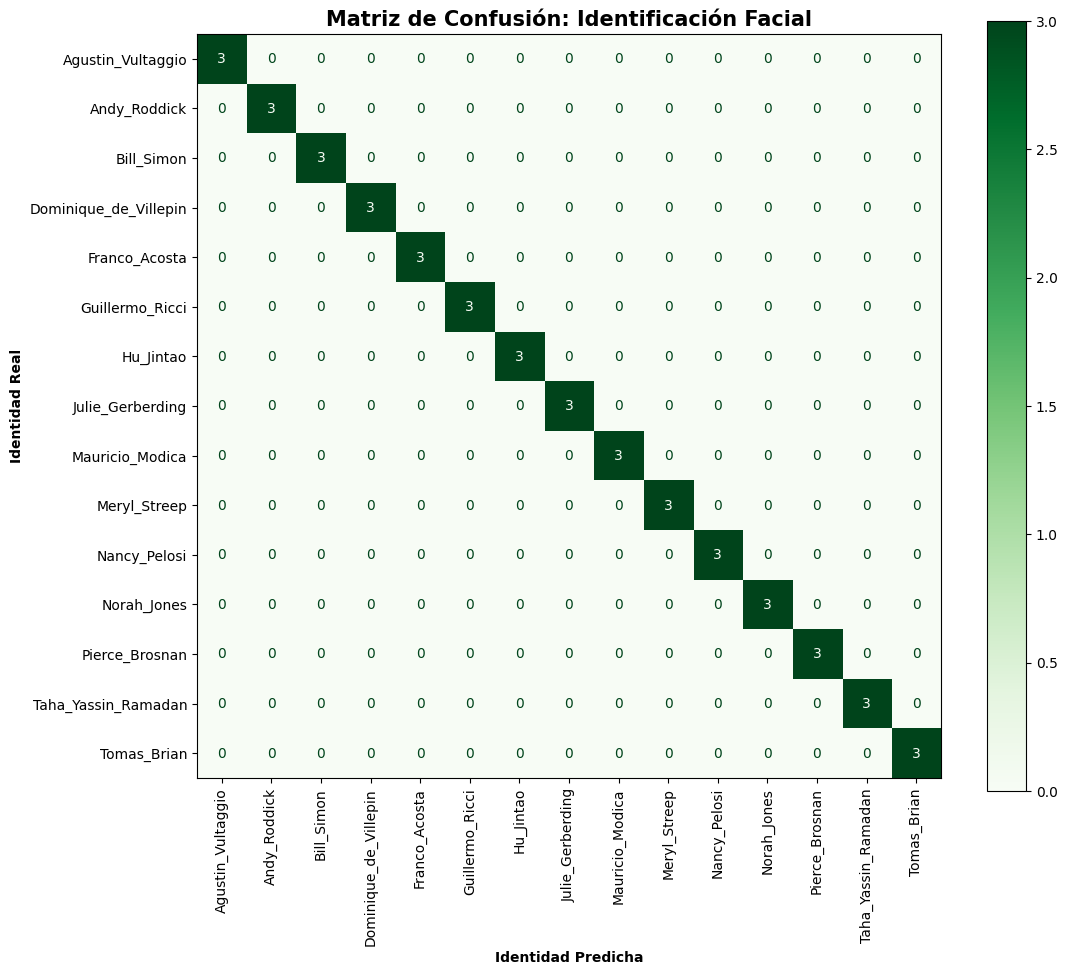

In [22]:
# --- PASO 3: Visualización de la Matriz de Confusión ---
fig, ax = plt.subplots(figsize=(12, 10))

# Generamos la matriz comparando etiquetas reales vs predichas
cm = confusion_matrix(test_labels_names, pred_labels_names, labels=le.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Greens", xticks_rotation='vertical', ax=ax, values_format='d')

plt.title("Matriz de Confusión: Identificación Facial", fontsize=15, fontweight='bold')
plt.xlabel("Identidad Predicha", fontweight='bold')
plt.ylabel("Identidad Real", fontweight='bold')
plt.show()

Vamos a analizar que tan parecidos son las personas entre sí, mostrando dos imágenes por persona.

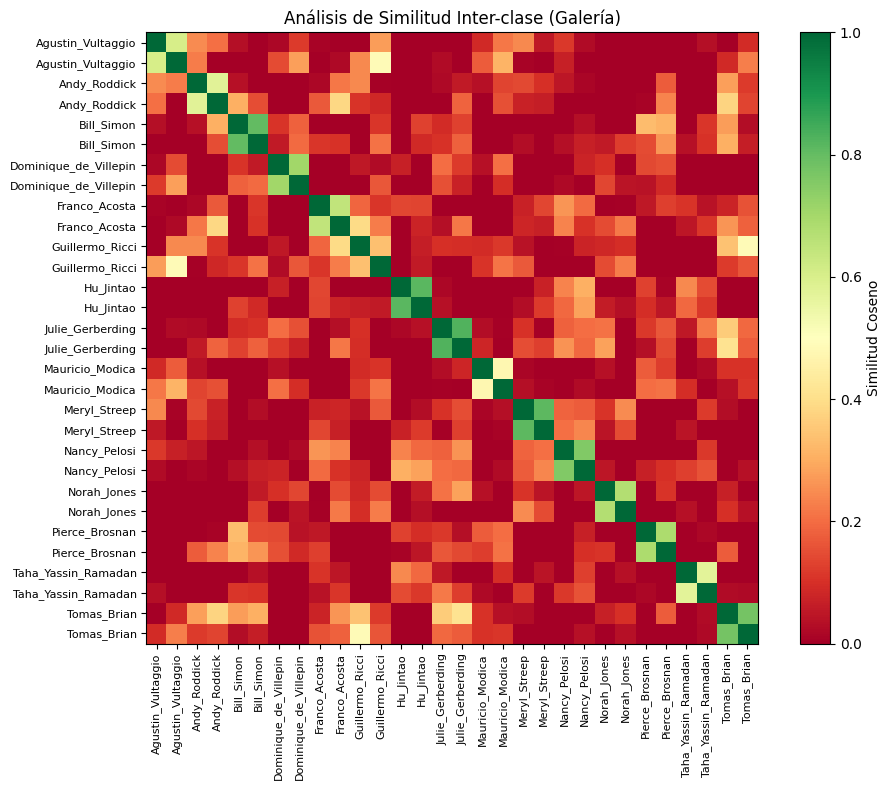

In [23]:
# Matriz de Similitud Visual 
indices_muestra = []
for nombre in np.unique(train_labels_names):
    # Buscamos índices en el set de entrenamiento
    idx = np.where(train_labels_names == nombre)[0][:2]
    indices_muestra.extend(idx)

# Extraemos la muestra
emb_small = train_embeddings[indices_muestra]
lab_small = train_labels_names[indices_muestra]

# Calculamos similitudes cruzadas
sim_small = cosine_similarity(emb_small, emb_small)

# Visualización
plt.figure(figsize=(10, 8))
plt.imshow(sim_small, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(label='Similitud Coseno')

ticks = range(len(lab_small))
plt.xticks(ticks, lab_small, rotation=90, fontsize=8)
plt.yticks(ticks, lab_small, fontsize=8)

plt.title("Análisis de Similitud Inter-clase (Galería)")
plt.tight_layout()
plt.show()

Se puede apreciar que si comparamos dos imagenes distintas de una misma persona tendremos una confianza mayor al 50% en que las clasifique correctamente

# Fine Tuning

Utilizamos un modelo pre-entrenado de Resnet. Al hacer fine-tuning, aprovechamos esa base y solo "ajustamos" las últimas capas para que reconozca mejor los rostros

In [24]:
# Definir número de clases 
num_clases = len(le.classes_)

# Cargar modelo para CLASIFICACIÓN 
# Al poner classify=True, reemplaza la última capa por una Linear con num_clases
modelo = InceptionResnetV1(
    pretrained='vggface2', 
    classify=True, 
    num_classes=num_clases
).to(device)

# Estrategia de Congelamiento (Transfer Learning) 
# Empezamos congelando TODO el backbone para entrenar solo la nueva "cabeza"
for param in modelo.parameters():
    param.requires_grad = False

# Descongelamos solo la capa de salida (logits)
for param in modelo.logits.parameters():
    param.requires_grad = True

#  Configuración de Entrenamiento 
criterion = nn.CrossEntropyLoss()
# Solo optimizamos los parámetros que tienen requires_grad = True
optimizer = optim.Adam(filter(lambda p: p.requires_grad, modelo.parameters()), lr=0.001)

print(f"✅ Modelo listo para entrenar {num_clases} clases.")

✅ Modelo listo para entrenar 15 clases.


In [25]:
# Bucle de Entrenamiento 
epochs = 10
print("🚀 Iniciando Fine-tuning...")

for epoch in range(epochs):
    modelo.train() # Modo entrenamiento (activa Dropout y BatchNorm)
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        
        # Forward
        output = modelo(imgs)
        loss = criterion(output, labels)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Métricas
        running_loss += loss.item()
        _, predicted = torch.max(output, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
    
    # --- VALIDACIÓN AL FINAL DE CADA ÉPOCA ---
    modelo.eval()
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            output = modelo(imgs)
            _, predicted = torch.max(output, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
            
    print(f"Época [{epoch+1}/{epochs}] | "
          f"Loss: {running_loss/len(train_loader):.4f} | "
          f"Train Acc: {100 * correct_train/total_train:.2f}% | "
          f"Test Acc: {100 * correct_test/total_test:.2f}%")

🚀 Iniciando Fine-tuning...
Época [1/10] | Loss: 2.1369 | Train Acc: 42.78% | Test Acc: 97.78%
Época [2/10] | Loss: 0.8695 | Train Acc: 93.33% | Test Acc: 97.78%
Época [3/10] | Loss: 0.4343 | Train Acc: 92.22% | Test Acc: 97.78%
Época [4/10] | Loss: 0.3205 | Train Acc: 95.00% | Test Acc: 100.00%
Época [5/10] | Loss: 0.1903 | Train Acc: 95.56% | Test Acc: 100.00%
Época [6/10] | Loss: 0.2612 | Train Acc: 93.89% | Test Acc: 100.00%
Época [7/10] | Loss: 0.2569 | Train Acc: 91.11% | Test Acc: 100.00%
Época [8/10] | Loss: 0.1784 | Train Acc: 96.11% | Test Acc: 100.00%
Época [9/10] | Loss: 0.1888 | Train Acc: 95.56% | Test Acc: 100.00%
Época [10/10] | Loss: 0.1888 | Train Acc: 96.67% | Test Acc: 100.00%


Se observa que en las primeras epocas la precision del Test es mucho mayor a la del Train, esto ocurre ya que al usar Data Augmentation le damos al modelo imagenes distorcionadas, lo que hace que su clasificacion sea mas dificil, en cambio, el dataset de Test está limpio. 
Esto indica que el modelo esta aprendiendo a generalizar, y logra converger rapidamente 

# Inferencia 

Cargamos una imagen nueva que el modelo no conoce para realizar una inferencia

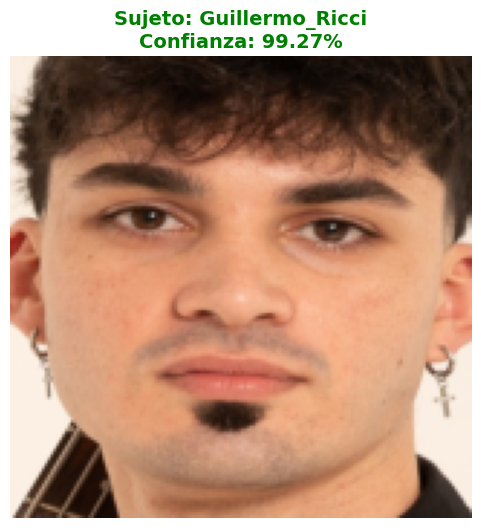

In [26]:
def inferencia_rostro(path_imagen, modelo, detector, le, device):
    # Cargar y Detectar
    img_pil = Image.open(path_imagen).convert('RGB')
    cara_tensor = detector(img_pil)
    
    if cara_tensor is None:
        print("❌ No se detectó ningún rostro.")
        return

    # Si detectó varias caras, cara_tensor es [N, 3, 160, 160]
    # Si detectó una sola, es [3, 160, 160]
    if cara_tensor.ndim == 4:
        # Tomamos solo la primera cara detectada
        cara_tensor = cara_tensor[0] 

    # Preprocesamiento
    # Rango 0-255
    cara_prep = ((cara_tensor + 1.0) * 127.5).clamp(0, 255).to(torch.uint8)
    
    # Normalización ImageNet
    cara_prep = cara_prep.to(torch.float32) / 255.0
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    cara_prep = (cara_prep - mean) / std
    
    # Inferencia
    modelo.eval()
    with torch.no_grad():
        input_tensor = cara_prep.unsqueeze(0).to(device)
        output = modelo(input_tensor)
        
        probs = F.softmax(output, dim=1)
        prob_max, class_idx = torch.max(probs, 1)
        
        nombre_predicho = le.inverse_transform([class_idx.item()])[0]
        confianza = prob_max.item() * 100

    # Visualización
    plt.figure(figsize=(6, 6))
    img_show = cara_tensor.permute(1, 2, 0).cpu().numpy()
    img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min() + 1e-8)
    
    plt.imshow(img_show)
    plt.title(f"Sujeto: {nombre_predicho}\nConfianza: {confianza:.2f}%", 
              fontsize=14, fontweight='bold', 
              color='green' if confianza > 70 else 'orange')
    plt.axis('off')
    plt.show()

PATH_PRUEBA = "src/data/inferencia/inferencia.jpg" 

if Path(PATH_PRUEBA).exists():
    inferencia_rostro(PATH_PRUEBA, modelo, detector, le, device)
else:
    print(f"Esperando que carguen una imagen en {PATH_PRUEBA}")

Se identifica la clase con la probabilidad más alta y se utiliza el LabelEncoder (le) para traducir el índice numérico al nombre real del sujeto. En este caso, el sistema alcanzó un 99.27% de confianza, lo que valida la eficacia del entrenamiento.

# Modelo Guardado

Guardamos el modelo final en **src/models/inception_resnet_final.pth**

In [28]:
# Definir rutas
dst = Path("src/models")
dst.mkdir(parents=True, exist_ok=True)

modelo.classify = False

model_path = dst / "inception_resnet_final.pth"
encoder_path = dst / "label_encoder.pkl"

# Guardar el modelo y el encoder
torch.save(modelo, model_path)
joblib.dump(le, encoder_path)

print(f"✅ Modelo guardado en 'MODO EXTRACTOR' (512-d): {model_path}")
print(f"✅ LabelEncoder guardado por seguridad: {encoder_path}")

# Verificación de Carga (Simulando el funcionamiento del Backend)
print("\n--- Verificación de Carga ---")
try:
    # Cargamos con weights_only=False por la versión de PyTorch
    loaded_model = torch.load(model_path, map_location="cpu", weights_only=False).eval()
    
    with torch.no_grad():
        # Creamos una imagen aleatoria de prueba
        test_input = torch.randn(1, 3, 160, 160)
        output = loaded_model(test_input)
        
    print(f"🚀 Carga OK")
    print(f"Salida del modelo: {output.shape}") 
    
    if output.shape[1] == 512:
        print("✅ ¡Perfecto! El modelo está entregando embeddings de 512 dimensiones.")
    else:
        print(f"⚠️ Atención: La salida es de {output.shape[1]}, se esperaban 512.")

except Exception as e:
    print(f"❌ Error en la verificación: {e}")

✅ Modelo guardado en 'MODO EXTRACTOR' (512-d): src\models\inception_resnet_final.pth
✅ LabelEncoder guardado por seguridad: src\models\label_encoder.pkl

--- Verificación de Carga ---
🚀 Carga OK
Salida del modelo: torch.Size([1, 512])
✅ ¡Perfecto! El modelo está entregando embeddings de 512 dimensiones.


Link al modelo guardado en Google Drive: 
https://drive.google.com/file/d/1Y3hdw3qLPk19y0vFRqb3l50VPDefLk-k/view?usp=drive_link

# Carga en la base vectorial

In [29]:
# Configuración de rutas e importaciones 
sys.path.insert(0, "src")
from lib.storage.embedding_store import EmbeddingStore
from lib.schemas import EmbeddingRecord

# Inicializar el almacén
store = EmbeddingStore(Path("src/data/embeddings.json"))

# Limpiamos para una carga fresca
store.save([])

print(f"🚀 Cargando {len(train_embeddings)} embeddings en la base vectorial...")

for i in range(len(train_embeddings)):
    # Obtenemos los datos del set de entrenamiento 
    emb = train_embeddings[i]
    label = train_labels_names[i]
    # Usamos train_paths[i]
    path_img = train_paths[i] 
    
    record = EmbeddingRecord(
        id_imagen=str(uuid4()),
        embedding=emb.tolist(),          # JSON no entiende arrays de Numpy, pasamos a lista
        path=str(path_img),              # Guardamos la ruta para poder mostrar la foto luego
        etiqueta=label,
        metadata={
            "source": "training_set",
            "alignment": "MTCNN",
            "model": "InceptionResnetV1_vggface2"
        }
    )
    
    store.append(record)

# Verificación final
records = store.all()
print(f"✅ Proceso finalizado.")
print(f"Total en base: {len(records)} registros.")

# Visualización de control 
print("\n--- Muestra de la Base de Datos ---")
# Mostramos un registro cada tanto para verificar diversidad
for r in records[::max(1, len(records)//5)]: 
    print(f"Identidad: {r.etiqueta:20s} | Path: {Path(r.path).name}")

🚀 Cargando 180 embeddings en la base vectorial...
✅ Proceso finalizado.
Total en base: 180 registros.

--- Muestra de la Base de Datos ---
Identidad: Andy_Roddick         | Path: Andy_Roddick_0011.jpg
Identidad: Meryl_Streep         | Path: Meryl_Streep_0006.jpg
Identidad: Andy_Roddick         | Path: Andy_Roddick_0002.jpg
Identidad: Andy_Roddick         | Path: Andy_Roddick_0004.jpg
Identidad: Nancy_Pelosi         | Path: Nancy_Pelosi_0004.jpg


# Carga en pgvector

In [30]:
# Configuración de rutas e importaciones
sys.path.insert(0, "src")

# Configuración de la base de datos
pg = PgVectorEmbeddingStore(
    host="localhost",
    port="5432",
    dbname="faces",         
    user="faces_user", 
    password="faces_pass",
    embedding_dim=512       # Dimensión de InceptionResnetV1
)

# Cargar datos del JSON 
JSON_PATH = Path("src/data/embeddings.json")

if JSON_PATH.exists():
    with open(JSON_PATH, 'r') as f:
        data_json = json.load(f)
    print(f"✓ Archivo JSON cargado con {len(data_json)} registros.")
else:
    print(f"❌ No se encontró el archivo en {JSON_PATH}")

# Limpiar registros previos para evitar duplicados
try:
    with pg.conn.cursor() as cur:
        cur.execute("DELETE FROM embeddings")
        pg.conn.commit()
    print("✓ Tabla en pgvector limpiada correctamente.")
except Exception as e:
    print(f"⚠️ Aviso: No se pudo limpiar la tabla (quizás no existe aún): {e}")

# Insertar los registros en la base vectorial
print("🚀 Iniciando volcado de datos a pgvector...")

for registro in data_json:
    record = EmbeddingRecord(
        id_imagen=registro.get('id_imagen', str(uuid4())),
        embedding=registro['embedding'],
        path=registro.get('path', 'unknown'),       
        etiqueta=registro.get('etiqueta', 'N/A'),   
        metadata=registro.get('metadata', {})
    )
    
    pg.append(record)

# Verificación final
records = pg.all()
print(f"\n✅ ¡ÉXITO! {len(records)} embeddings cargados en pgvector.")

# Muestra de seguridad
if records:
    r = records[0]
    print(f"Prueba de registro -> Identidad: {r.etiqueta} | ID: {r.id_imagen[:8]}...")

✓ Archivo JSON cargado con 180 registros.
✓ Tabla en pgvector limpiada correctamente.
🚀 Iniciando volcado de datos a pgvector...

✅ ¡ÉXITO! 180 embeddings cargados en pgvector.
Prueba de registro -> Identidad: Andy_Roddick | ID: e188b866...
